In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/Users/liukebing/Desktop/Data Analysis/Data/Brazilian E-commerce Dataset by Olist/olist_delay_review_freight.csv')

In [3]:
df.head()

,customer_unique_id,delivery_delay,review_score,freight_ratio,is_delayed,is_high_score,is_repurchased
0,0000366f3b9a7992bf8c76cfdf3221e2,-4.0,5.0,0.084567,0.0,1.0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,-4.0,4.0,0.304892,0.0,1.0,0
2,0000f46a3911fa3c0805444483337064,-1.0,3.0,0.199722,0.0,0.0,0
3,0000f6ccb0745a6a4b88665a16c9f078,-11.0,4.0,0.404172,0.0,1.0,0
4,0004aac84e0df4da2b147fca70cf8255,-7.0,5.0,0.085784,0.0,1.0,0


In [7]:
df=df[['delivery_delay','freight_ratio','is_repurchased']].dropna()

In [8]:
df.head()

,delivery_delay,freight_ratio,is_repurchased
0,-4.0,0.084567,0
1,-4.0,0.304892,0
2,-1.0,0.199722,0
3,-11.0,0.404172,0
4,-7.0,0.085784,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86522 entries, 0 to 86529
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   delivery_delay  86522 non-null  float64
 1   freight_ratio   86522 non-null  float64
 2   is_repurchased  86522 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 2.6 MB


In [10]:
df.describe()

,delivery_delay,freight_ratio,is_repurchased
count,86522.000000,86522.000000,86522.000000
mean,-11.224163,0.208552,0.127725
std,10.117527,0.126628,0.333785
min,-146.000000,0.000000,0.000000
25%,-16.000000,0.115667,0.000000
50%,-12.000000,0.182970,0.000000
75%,-7.000000,0.275930,0.000000
max,188.000000,0.955451,1.000000


In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [12]:
X_tree = df[['delivery_delay', 'freight_ratio']]
y_tree = df['is_repurchased']

In [13]:
clf = DecisionTreeClassifier(max_depth=2, random_state=42, class_weight='balanced')
clf.fit(X_tree, y_tree)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


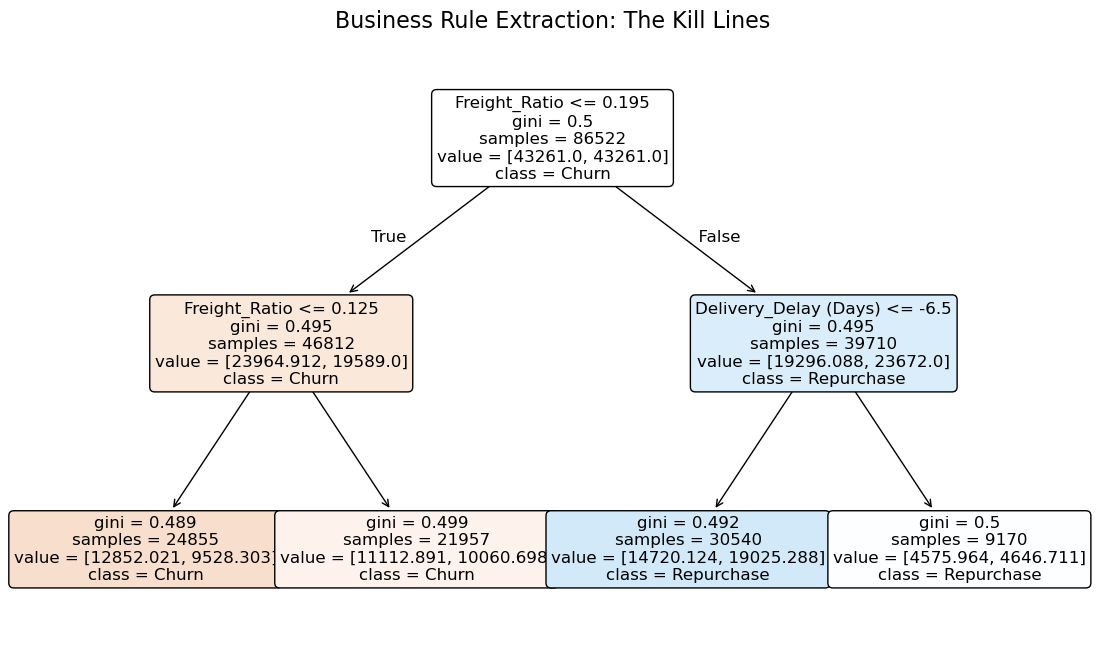

In [14]:
plt.figure(figsize=(14, 8))
plot_tree(clf, 
          feature_names=['Delivery_Delay (Days)', 'Freight_Ratio'], 
          class_names=['Churn', 'Repurchase'], 
          filled=True, 
          rounded=True,
          fontsize=12)
plt.title("Business Rule Extraction: The Kill Lines", fontsize=16)
plt.show()

In [22]:
df1=pd.read_csv('/Users/liukebing/Desktop/Data Analysis/Data/Brazilian E-commerce Dataset by Olist/olist_decision_tree.csv')

In [23]:
df1=df1[['price','delivery_delay','freight_value','is_repurchased']].dropna()

In [24]:
df1.head()

,price,delivery_delay,freight_value,is_repurchased
0,129.90,-4.0,12.00,0
1,18.90,-4.0,8.29,0
2,69.00,-1.0,17.22,0
3,25.99,-11.0,17.63,0
4,180.00,-7.0,16.89,0


In [25]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86522 entries, 0 to 86529
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           86522 non-null  float64
 1   delivery_delay  86522 non-null  float64
 2   freight_value   86522 non-null  float64
 3   is_repurchased  86522 non-null  int64  
dtypes: float64(3), int64(1)
memory usage: 3.3 MB


In [26]:
df1.describe()

,price,delivery_delay,freight_value,is_repurchased
count,86522.000000,86522.000000,86522.000000,86522.000000
mean,126.013958,-11.225388,20.100012,0.127725
std,191.250866,10.118818,15.619331,0.333785
min,0.850000,-146.000000,0.000000,0.000000
25%,41.490000,-16.000000,13.370000,0.000000
50%,79.000000,-12.000000,16.320000,0.000000
75%,139.900000,-7.000000,21.150000,0.000000
max,6735.000000,188.000000,409.680000,1.000000


In [27]:
X_tree1 = df1[['price','delivery_delay', 'freight_value']]
y_tree1 = df1['is_repurchased']

In [36]:
clf1 = DecisionTreeClassifier(max_depth=2, random_state=42, class_weight='balanced')
clf1.fit(X_tree1, y_tree1)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


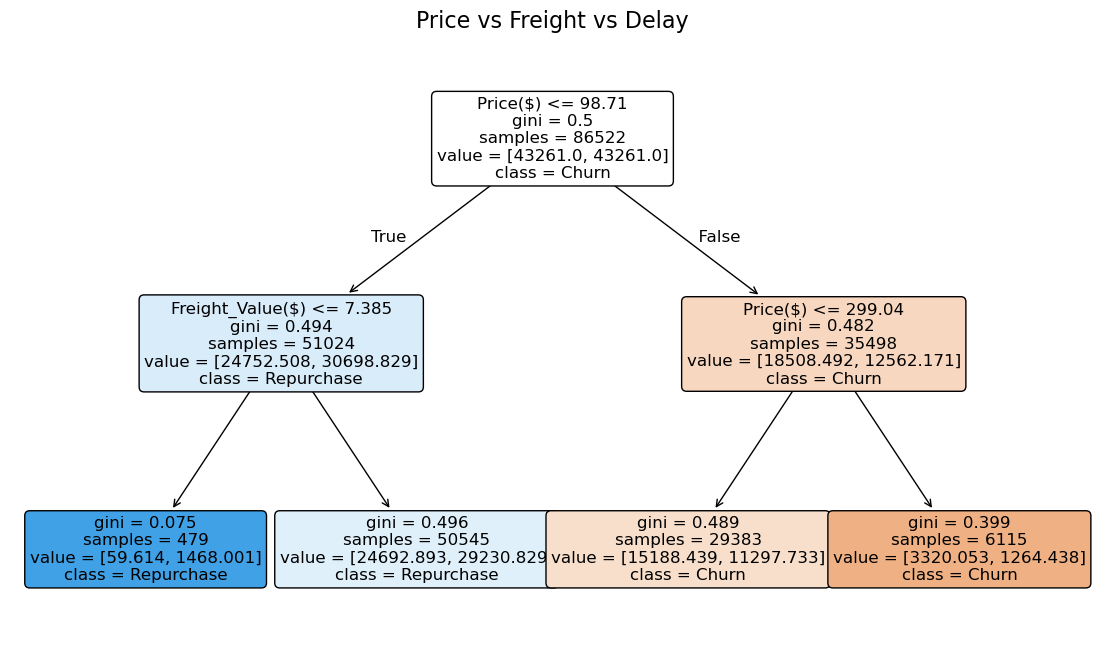

In [37]:
plt.figure(figsize=(14, 8))
plot_tree(clf1, 
          feature_names=['Price($)','Delivery_Delay (Days)','Freight_Value($)'], 
          class_names=['Churn', 'Repurchase'], 
          filled=True, 
          rounded=True,
          fontsize=12)
plt.title("Price vs Freight vs Delay", fontsize=16)
plt.show()

In [38]:
import statsmodels.api as sm

In [65]:
features = ['price', 'freight_value', 'is_delayed']

In [66]:
df2=pd.read_csv('/Users/liukebing/Desktop/Data Analysis/Data/Brazilian E-commerce Dataset by Olist/olist_decision_tree.csv')
model_df2 = df2[features + ['is_repurchased']].dropna()

In [67]:
X_final = model_df2[features]
y_final = model_df2['is_repurchased']

In [68]:
X_final = sm.add_constant(X_final)
logit_model = sm.Logit(y_final, X_final)
final_result = logit_model.fit()
print(final_result.summary())

Optimization terminated successfully.
         Current function value: 0.377544
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         is_repurchased   No. Observations:                86522
Model:                          Logit   Df Residuals:                    86518
Method:                           MLE   Df Model:                            3
Date:                Sat, 30 May 2026   Pseudo R-squ.:                 0.01176
Time:                        13:27:48   Log-Likelihood:                -32666.
converged:                       True   LL-Null:                       -33055.
Covariance Type:            nonrobust   LLR p-value:                2.961e-168
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.6357      0.019    -84.759      0.000      -1.674      -1.598
price            -0.

In [69]:
low_price_df2 = model_df2[model_df2['price'] <= 98.71].copy()
high_price_df2 = model_df2[model_df2['price'] > 98.71].copy()

In [70]:
def run_logit(df2, label):
    X = sm.add_constant(df2[['price', 'freight_value', 'is_delayed']])
    y = df2['is_repurchased']
    model = sm.Logit(y, X).fit(disp=0)
    print(model.summary())

In [71]:
run_logit(low_price_df2, "Low-ticket segment (<$98)")
run_logit(high_price_df2, "High-ticket segment (>$98)")

                           Logit Regression Results                           
Dep. Variable:         is_repurchased   No. Observations:                51024
Model:                          Logit   Df Residuals:                    51020
Method:                           MLE   Df Model:                            3
Date:                Sat, 30 May 2026   Pseudo R-squ.:                0.001975
Time:                        13:28:01   Log-Likelihood:                -21849.
converged:                       True   LL-Null:                       -21892.
Covariance Type:            nonrobust   LLR p-value:                 1.249e-18
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.4351      0.035    -40.646      0.000      -1.504      -1.366
price            -0.0042      0.001     -7.822      0.000      -0.005      -0.003
freight_value    -0.0037      0.002     